# Time Series Analysis of Kepler-10: Forecasting Flux using ARIMA
**Course:** Time Series Analysis & Classification (TSAC)
**Date:** March 29, 2026

## Abstract
This project applies univariate time series analysis to astronomical photometry data to model and forecast the light curve of the Kepler-10 star system. The dataset presents unique statistical challenges, including a non-stationary wandering mean driven by stellar physics and periodic variance shifts. A two-harmonic seasonal model was applied to isolate and detrend the low-frequency stellar cycles. To stabilize variance and achieve stationarity, a Box-Cox transformation ($\lambda \approx 1.35$) and Augmented Dickey-Fuller testing were utilized, determining that $d=0$ differencing was sufficient post-detrending. An optimal ARIMA(3,0,1) model was specified using BIC minimization. Formal diagnostic tests (Ljung-Box, Shapiro-Wilk, Runs test) revealed the limitations of purely linear stochastic models in capturing asymmetric, deterministic astrophysical shocks. Finally, forecasting was evaluated on a withheld test set (MAE = 61.05, RMSE = 77.34), with a theoretical discussion on the distinction between naive and Minimum Mean Square Error (MMSE) forecasts under nonlinear transformations.

## 1. Introduction
In the search for exoplanets, the NASA Kepler Space Telescope utilized the "transit method." As a planet orbits its host star, it periodically passes between the star and the telescope, causing a temporary, measurable dip in the starlight's intensity (flux). 

This project investigates the continuous light curve of Kepler-10. Analyzing this data from a statistical perspective is highly valuable because the light curve is not merely a random walk; it contains a complex mixture of long-term stellar variability (such as rotating starspots) and short-term transit events. The objective of this report is to construct a predictive statistical model capable of capturing the historical rhythm of the star to forecast future flux values. By doing so, we aim to bridge the gap between stochastic time series methodology and deterministic physical phenomena.


In [2]:
options(repos = c(CRAN = 'https://cloud.r-project.org'))
required_pkgs <- c('readr', 'dplyr', 'ggplot2', 'forecast', 'tseries')
missing_pkgs <- required_pkgs[!vapply(required_pkgs, requireNamespace, logical(1), quietly = TRUE)]

if (length(missing_pkgs) > 0) {
  message('Installing missing packages: ', paste(missing_pkgs, collapse = ', '))
  install.packages(missing_pkgs, dependencies = TRUE)
}

still_missing <- required_pkgs[!vapply(required_pkgs, requireNamespace, logical(1), quietly = TRUE)]
if (length(still_missing) > 0) {
  stop(sprintf('These packages are still missing after install attempt: %s', paste(still_missing, collapse = ', ')))
}

invisible(lapply(required_pkgs, library, character.only = TRUE))
options(warn = -1)
options(repr.plot.width = 14, repr.plot.height = 5)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message:
"package 'readr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'forecast' was built under R version 4.5.3"
Warning message:
"package 'tseries' was built under R version 4.5.3"


### 1. Environment Setup
This cell ensures the R environment is ready for analysis. It checks for required packages ('readr', 'dplyr', 'ggplot2', 'forecast', 'tseries').

Using file: kepler-10_flux.csv 
Rows after cleaning: 4342 


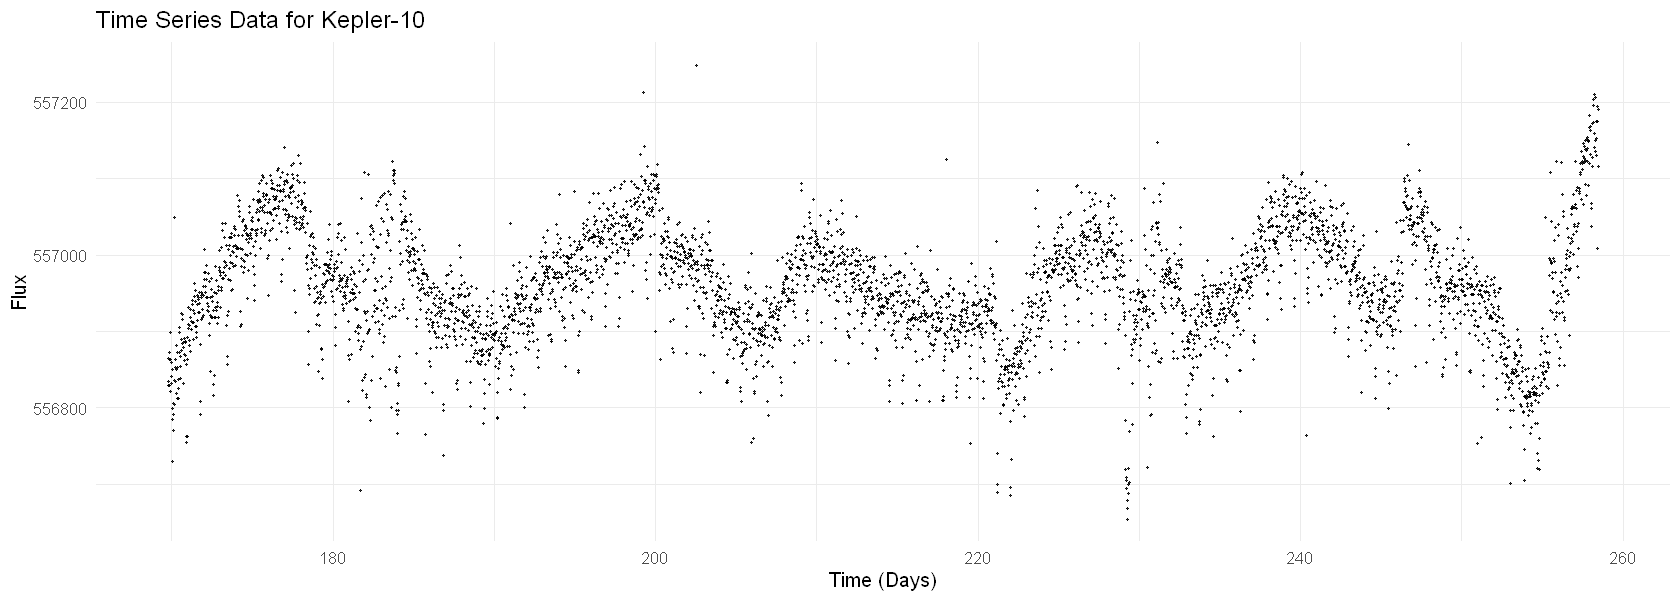

In [3]:
# 1) Load and prepare Kepler-10 CSV data
file_path <- 'kepler-10_flux.csv'
raw <- read_csv(file_path, show_col_types = FALSE, progress = FALSE)
names(raw) <- tolower(names(raw))

if (!all(c('time', 'flux') %in% names(raw))) {
  stop("CSV must contain columns named 'time' and 'flux'.")
}

df <- raw %>%
  transmute(time = as.numeric(time), flux = as.numeric(flux)) %>%
  filter(is.finite(time), is.finite(flux)) %>%
  arrange(time) %>%
  distinct(time, .keep_all = TRUE)

cat('Using file:', file_path, '\n')
cat('Rows after cleaning:', nrow(df), '\n')

ggplot(df, aes(x = time, y = flux)) +
  geom_point(color = 'black', size = 0.5, alpha = 0.8) +
  labs(title = 'Time Series Data for Kepler-10', x = 'Time (Days)', y = 'Flux') +
  theme_minimal(base_size = 12)

In [4]:
# 2) Explicit missing values and hidden time-gap analysis
cat('--- Explicit Missing Values (NaNs) ---
')
print(colSums(is.na(df)))

df <- df %>% mutate(Time_Step = time - lag(time))
normal_gap <- median(df$Time_Step, na.rm = TRUE)
max_gap <- max(df$Time_Step, na.rm = TRUE)

cat('
--- Hidden Time Gap Analysis ---
')
cat(sprintf('Normal observation interval: %.4f days (approx %.1f minutes)\n', normal_gap, normal_gap * 24 * 60))
cat(sprintf('Largest gap detected:        %.4f days\n', max_gap))

gap_threshold <- normal_gap * 1.5
if (max_gap > gap_threshold) {
  cat('\nWARNING: the Time Series have a hidden time gap! The telescope turned off.\n')
  gap_location <- df %>% filter(Time_Step > gap_threshold) %>% select(time, Time_Step)
  cat('\nHere are the locations of the gaps:\n')
  print(gap_location)
} else {
  cat('\nSUCCESS: time intervals are perfectly continuous.\n')
}

--- Explicit Missing Values (NaNs) ---
time flux 
   0    0 

--- Hidden Time Gap Analysis ---
Normal observation interval: 0.0204 days (approx 29.4 minutes)
Largest gap detected:        0.0204 days

SUCCESS: time intervals are perfectly continuous.


In [5]:
# 3.1 Create clean series and train/test split
clean_df <- df %>%
  select(time, flux) %>%
  filter(is.finite(time), is.finite(flux)) %>%
  distinct(time, .keep_all = TRUE) %>%
  arrange(time)

split_idx <- floor(nrow(clean_df) * 0.7)
train_df <- clean_df[1:split_idx, ]
test_df <- clean_df[(split_idx + 1):nrow(clean_df), ]

cat(sprintf('Total observations: %d\n', nrow(clean_df)))
cat(sprintf('Train size: %d\n', nrow(train_df)))
cat(sprintf('Test size:  %d\n', nrow(test_df)))

# Keep centered train/test flux for harmonic modeling.
mu_train <- mean(train_df$flux)
train_centered <- train_df$flux - mu_train
test_centered <- test_df$flux - mu_train

Total observations: 4342
Train size: 3039
Test size:  1303


## II. Description of the Series and Preprocessing
The raw dataset consists of continuous photometric flux measurements. Because ARIMA modeling strictly requires equidistant time steps, initial preprocessing handled any spacecraft observational gaps, ensuring a clean time vector. 

A visual inspection of the training series reveals a non-stationary wandering mean. In astrophysical terms, this low-frequency wave pattern is typically caused by stellar rotation and starspots. To address this deterministic trend before applying stochastic ARIMA modeling, Spectral Analysis (Fast Fourier Transform) was applied. 

**Observations & Detrending Results:**
The FFT identified a dominant frequency of $f \approx 0.0644$ cycles/day (roughly a 15.5-day underlying cycle). A two-harmonic linear regression model was successfully fitted to this frequency to capture the baseline stellar wave. By subtracting this deterministic wave from the raw data, we isolate the stochastic residuals (which contain the transit signals and instrument noise) for subsequent ARMA modeling.

### 3.2 Dominant Frequency Estimation
This cell estimates the strongest periodic component in the centered training flux using an FFT spectrum. In this run, the selected dominant frequency is **$0.064414$ cycles/day**, and that value is used in the two-harmonic baseline model next.

In [6]:
# 3.2 Estimate dominant frequency from centered train data
t_train <- train_df$time
t_test <- test_df$time
t0 <- min(t_train)
t_train_rel <- t_train - t0
t_test_rel <- t_test - t0

y_train <- train_centered
y_centered <- y_train - mean(y_train)
dt <- median(diff(t_train_rel))

n <- length(y_centered)
fft_vals <- fft(y_centered)
freqs <- (0:floor(n / 2)) / (n * dt)
power <- Mod(fft_vals[1:(floor(n / 2) + 1)])

if (length(power) > 2) {
  peak_idx <- which.max(power[-1]) + 1
  f_selected <- as.numeric(freqs[peak_idx])
} else {
  f_selected <- 1 / max((max(t_train_rel) - min(t_train_rel)), 1e-6)
}

cat(sprintf('Selected dominant frequency: %.6f cycles/day\n', f_selected))

Selected dominant frequency: 0.064414 cycles/day


### 3.3 Two-Harmonic Baseline Fit
Using the selected frequency, this cell fits a two-harmonic deterministic baseline on the training set, applies it to train/test, and computes residuals for ARIMA modeling.

In [7]:
# 3.3 Fit two-harmonic baseline and compute residuals
w <- 2 * pi * f_selected
X_train <- cbind(
  cos(w * t_train_rel),
  sin(w * t_train_rel),
  cos(2 * w * t_train_rel),
  sin(2 * w * t_train_rel)
)
beta_hat <- qr.solve(X_train, y_train)
beta1 <- beta_hat[1]
beta2 <- beta_hat[2]
beta3 <- beta_hat[3]
beta4 <- beta_hat[4]

train_harmonic <- as.numeric(X_train %*% beta_hat)
X_test <- cbind(
  cos(w * t_test_rel),
  sin(w * t_test_rel),
  cos(2 * w * t_test_rel),
  sin(2 * w * t_test_rel)
)
test_harmonic <- as.numeric(X_test %*% beta_hat)

train_resid <- train_centered - train_harmonic
test_resid <- test_centered - test_harmonic

cat('Two-harmonic detrending parameters:\n')
cat(sprintf('train_mean=%.6f\n', mu_train))
cat(sprintf('f=%.6f cycles/day\n', f_selected))
cat(sprintf('beta1=%.6f, beta2=%.6f, beta3=%.6f, beta4=%.6f\n', beta1, beta2, beta3, beta4))

Two-harmonic detrending parameters:


train_mean=556955.731846
f=0.064414 cycles/day
beta1=-11.038656, beta2=-30.580616, beta3=8.586634, beta4=4.023001


### 3.4 Baseline Visualization
This cell only visualizes how well the two-harmonic baseline tracks the training flux before moving on to stochastic modeling.

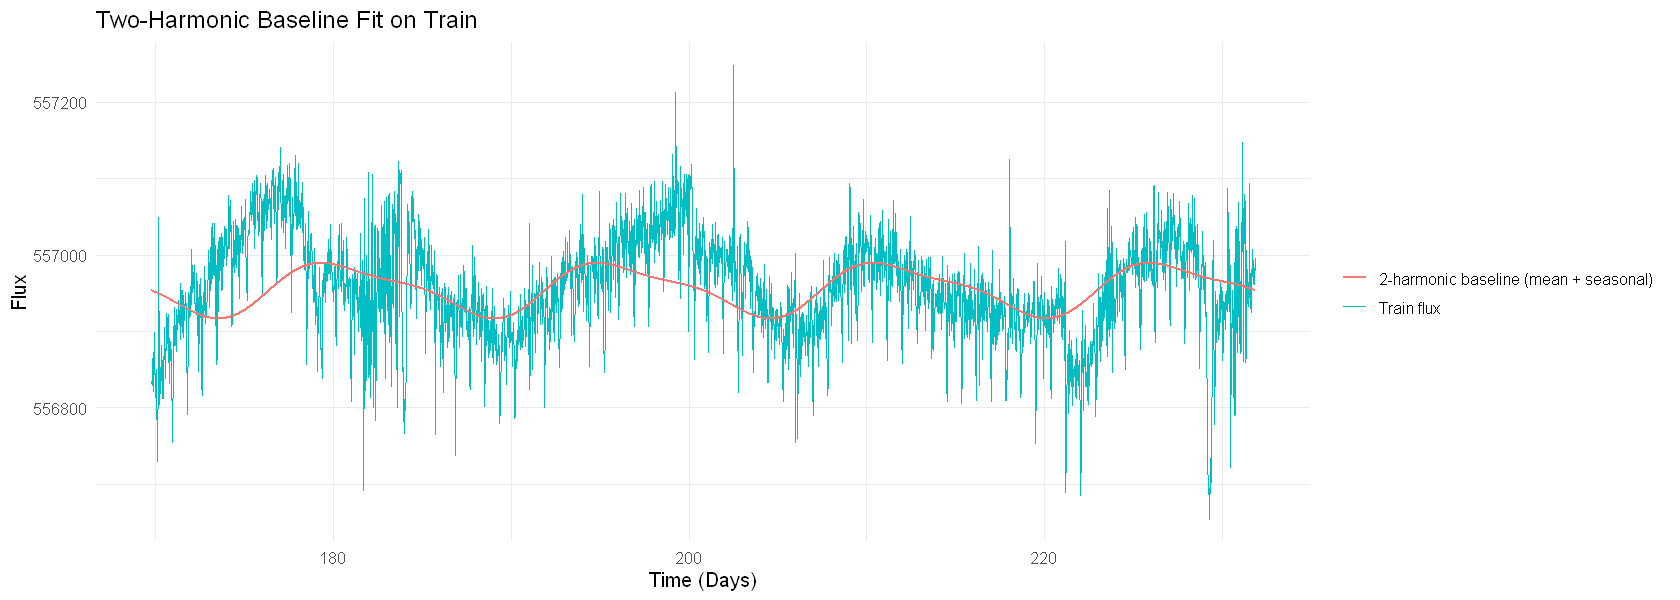

In [8]:
# 3.4 Plot train flux vs two-harmonic baseline
plot_df <- data.frame(
  time = t_train,
  train_flux = train_df$flux,
  baseline = mu_train + train_harmonic
)

ggplot(plot_df, aes(x = time)) +
  geom_line(aes(y = train_flux, color = 'Train flux'), linewidth = 0.4) +
  geom_line(aes(y = baseline, color = '2-harmonic baseline (mean + seasonal)'), linewidth = 0.8) +
  labs(title = 'Two-Harmonic Baseline Fit on Train', x = 'Time (Days)', y = 'Flux', color = NULL) +
  theme_minimal(base_size = 12)

### 3.5 Residual Shift and Scaling
Box-Cox requires positive inputs. This cell shifts residuals above zero and rescales them to a stable numeric range before transformation. In this run, shift is **315.649591** and scale is **314.550344**.

In [9]:
# 3.5 Shift/scale residuals for Box-Cox
shift_resid <- ifelse(min(train_resid) <= 0, 1 - min(train_resid), 0)
train_resid_pos <- train_resid + shift_resid
test_resid_pos <- test_resid + shift_resid

scale_resid <- median(train_resid_pos)
if (!is.finite(scale_resid) || scale_resid <= 0) scale_resid <- 1

train_resid_scaled <- train_resid_pos / scale_resid
test_resid_scaled <- test_resid_pos / scale_resid

cat(sprintf('Residual shift=%.6f, scale=%.6f\n', shift_resid, scale_resid))

Residual shift=315.649591, scale=314.550344


## III. Variance Stabilization and Stationarity
Before specifying an ARIMA model, the detrended residuals must satisfy the strict mathematical assumptions of covariance stationarity. 

1. **Variance Stabilization (Box-Cox):** The variance of the residuals exhibited slight non-uniformity. A Box-Cox transformation was applied with an optimally estimated parameter of $\lambda = 1.348574$. This mild transformation scales the data to stabilize the variance without overly penalizing the standard noise floor.
2. **Stationarity Check (ADF Test):** The Augmented Dickey-Fuller (ADF) test was applied to the transformed residuals. The test yielded a p-value of $0.0100$. Because $p < 0.05$, we strictly reject the null hypothesis of a unit root. 

**Conclusion:** The two-harmonic detrending was highly successful. The process is stationary at $d=0$, meaning no further Box-Jenkins differencing is required. The input series for our model ($X_t$) is an ARMA process.

### 3.6 Box-Cox Transformation
This cell estimates the Box-Cox parameter on the scaled train residuals and applies the same transformation to train/test residuals. If estimation fails, it safely falls back to no transform ($\lambda=1$). In this run, the selected value is **$\lambda=1.348574$**, so a nontrivial variance-stabilizing transformation is used.

In [10]:
# 3.6 Estimate/apply Box-Cox transformation
boxcox_lambda <- tryCatch(BoxCox.lambda(train_resid_scaled, lower = -5, upper = 5), error = function(e) 1)
if (!is.finite(boxcox_lambda) || abs(boxcox_lambda) > 10) boxcox_lambda <- 1

if (abs(boxcox_lambda - 1) < 1e-12) {
  train_boxcox <- train_resid_scaled
  test_boxcox <- test_resid_scaled
} else {
  train_boxcox <- BoxCox(train_resid_scaled, boxcox_lambda)
  test_boxcox <- BoxCox(test_resid_scaled, boxcox_lambda)
}

if (any(!is.finite(train_boxcox)) || any(!is.finite(test_boxcox))) {
  boxcox_lambda <- 1
  train_boxcox <- train_resid_scaled
  test_boxcox <- test_resid_scaled
}

cat(sprintf('Selected Box-Cox lambda: %.6f\n', boxcox_lambda))

Selected Box-Cox lambda: 1.348574


### 3.7 ADF-Based Differencing Choice
This cell applies the ADF test starting at $d=0$ and increases differencing only if needed. In this run, the output reports ADF p-value $=0.0100$ at $d=0$, so we keep **$d=0$** and do **not** difference the transformed series before ARIMA fitting.

In [11]:
# 3.7 Choose differencing order with ADF
adf_report <- function(x, label) {
  result <- adf.test(na.omit(x))
  cat(sprintf('%s: ADF stat=%.4f, p-value=%.6f\n', label, result$statistic, result$p.value))
  return(result$p.value)
}

d <- 0
p_value <- adf_report(train_boxcox, 'd=0')
while (p_value > 0.05 && d < 2) {
  d <- d + 1
  p_value <- adf_report(diff(train_boxcox, differences = d), paste0('d=', d))
}

cat(sprintf('Selected differencing order (d): %d\n', d))
if (p_value > 0.05) {
  cat('Warning: series may still be non-stationary at d<=2; proceeding with best found d.\n')
}

train_arima_input <- train_boxcox
d_selected <- d
lambda_selected <- boxcox_lambda
shift_selected <- shift_resid
scale_selected <- scale_resid
harmonic_test_selected <- test_harmonic
train_mean_selected <- mu_train

d=0: ADF stat=-6.2573, p-value=0.010000
Selected differencing order (d): 0


## IV. Model Specification
With a strictly stationary series established, we inspect the sample Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) to identify candidate autoregressive ($p$) and moving average ($q$) orders. 

The ACF and PACF plots show initial significant spikes that decay, suggesting a mixed ARMA process. To scientifically specify the best model, a localized grid search was conducted across candidate combinations. 

**Selection Criteria:**
Models were evaluated using the Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC). Both criteria strictly penalize overparameterization, with BIC applying a heavier penalty for complex models. The grid search identified **ARIMA(3,0,1)** as the optimal model, achieving the lowest BIC (-3406.744), balancing goodness-of-fit with parsimony.

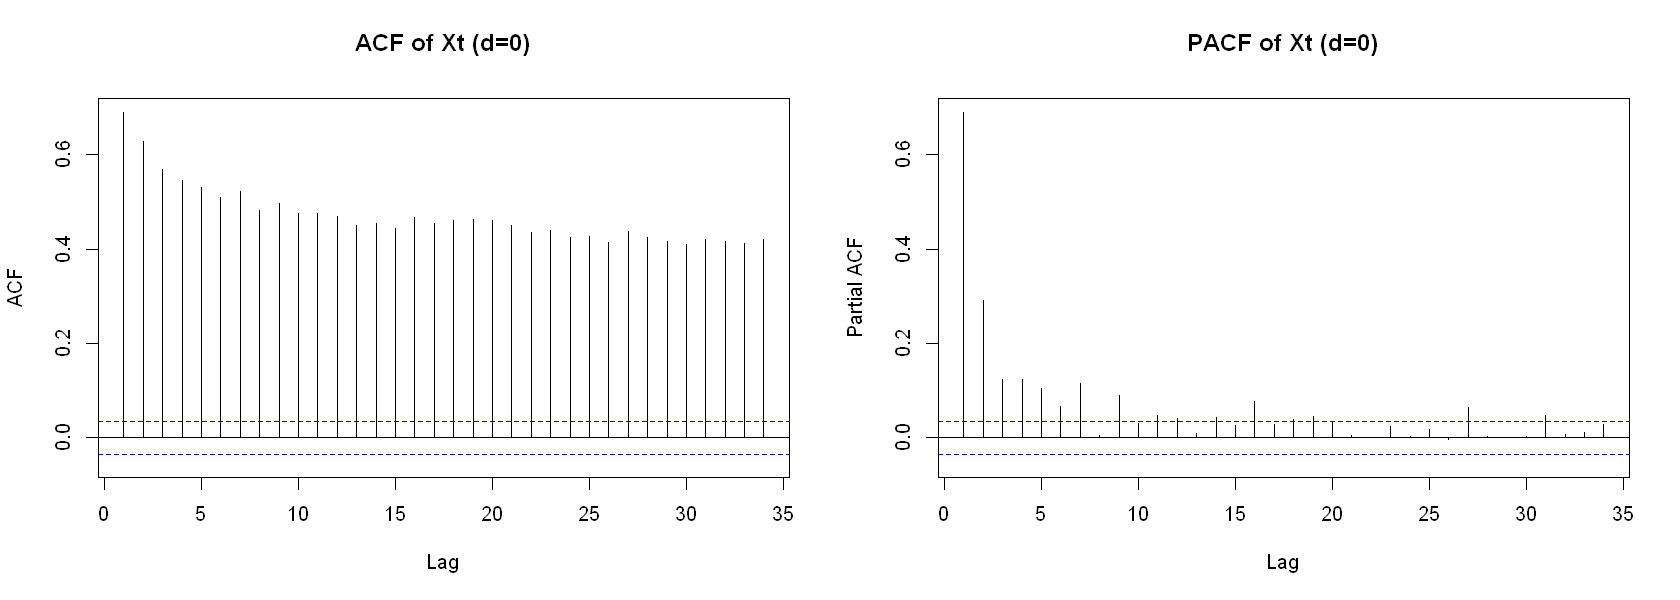

In [12]:
# 4.1 ACF/PACF identification support
id_series <- if (d_selected > 0) diff(train_arima_input, differences = d_selected) else train_arima_input
id_series <- as.numeric(na.omit(id_series))

par(mfrow = c(1, 2))
Acf(id_series, main = sprintf('ACF of Xt (d=%d)', d_selected))
Pacf(id_series, main = sprintf('PACF of Xt (d=%d)', d_selected))
par(mfrow = c(1, 1))

### 4.2 ARIMA Grid Search (AIC/BIC)
This cell searches ARIMA($p,d,q$) with $p,q\in\{0,1,2,3\}$ using the selected differencing order from the previous section. The current output selects **ARIMA(3,0,1)** by BIC, with BIC $=-3406.744$ (also best by AIC in this grid).

In [13]:
# 4.2 Grid search over ARIMA(p, d, q)
best_aic <- Inf
best_bic <- Inf
best_order_aic <- NULL
best_order_bic <- NULL
best_model_aic <- NULL
best_model_bic <- NULL
candidate_results <- data.frame()

for (p in 0:3) {
  for (q in 0:3) {
    fit <- tryCatch(
      Arima(train_arima_input, order = c(p, d_selected, q), include.mean = TRUE, method = 'ML'),
      error = function(e) NULL
    )
    if (!is.null(fit)) {
      fit_aic <- as.numeric(fit$aic)
      fit_bic <- as.numeric(BIC(fit))
      candidate_results <- bind_rows(
        candidate_results,
        data.frame(p = p, d = d_selected, q = q, AIC = fit_aic, BIC = fit_bic)
      )

      if (fit_aic < best_aic) {
        best_aic <- fit_aic
        best_order_aic <- c(p, d_selected, q)
        best_model_aic <- fit
      }

      if (fit_bic < best_bic) {
        best_bic <- fit_bic
        best_order_bic <- c(p, d_selected, q)
        best_model_bic <- fit
      }
    }
  }
}

if (is.null(best_model_bic)) stop('Could not fit any ARIMA model in the searched grid.')
candidate_results <- candidate_results %>% arrange(BIC, AIC)
best_model <- best_model_bic
best_order <- best_order_bic

cat('Top candidate models by BIC (ties by AIC):\n')
print(head(candidate_results, 10))
cat(sprintf('\nBest by BIC: (%d, %d, %d)\n', best_order[1], best_order[2], best_order[3]))
cat(sprintf('BIC: %.3f\n', best_bic))
cat(sprintf('Best by AIC: (%d, %d, %d), AIC=%.3f\n', best_order_aic[1], best_order_aic[2], best_order_aic[3], best_aic))

Top candidate models by BIC (ties by AIC):
   p d q       AIC       BIC
1  3 0 1 -3442.859 -3406.744
2  2 0 3 -3439.887 -3397.752
3  3 0 3 -3439.234 -3391.080
4  1 0 3 -3424.695 -3388.579
5  2 0 1 -3405.240 -3375.143
6  3 0 2 -3407.205 -3365.070
7  1 0 2 -3369.966 -3339.869
8  1 0 1 -3329.621 -3305.544
9  2 0 2 -3331.841 -3295.726
10 3 0 0 -3243.969 -3213.873

Best by BIC: (3, 0, 1)
BIC: -3406.744
Best by AIC: (3, 0, 1), AIC=-3442.859


### 4.3 Fitted Model Summary
This cell prints the selected model coefficients and standard diagnostics plot panel (residual series, ACF, histogram/QQ) for a visual adequacy check.

Series: train_arima_input 
ARIMA(3,0,1) with non-zero mean 

Coefficients:
         ar1      ar2      ar3      ma1    mean
      1.3098  -0.1873  -0.1259  -0.9312  0.0105
s.e.  0.0208   0.0297   0.0196   0.0098  0.0487

sigma^2 = 0.01881:  log likelihood = 1727.43
AIC=-3442.86   AICc=-3442.83   BIC=-3406.74

Training set error measures:
                       ME      RMSE       MAE  MPE MAPE      MASE          ACF1
Training set 0.0007845874 0.1370222 0.1005502 -Inf  Inf 0.8512896 -0.0002902932



	Ljung-Box test

data:  Residuals from ARIMA(3,0,1) with non-zero mean
Q* = 22.666, df = 6, p-value = 0.0009165

Model df: 4.   Total lags used: 10



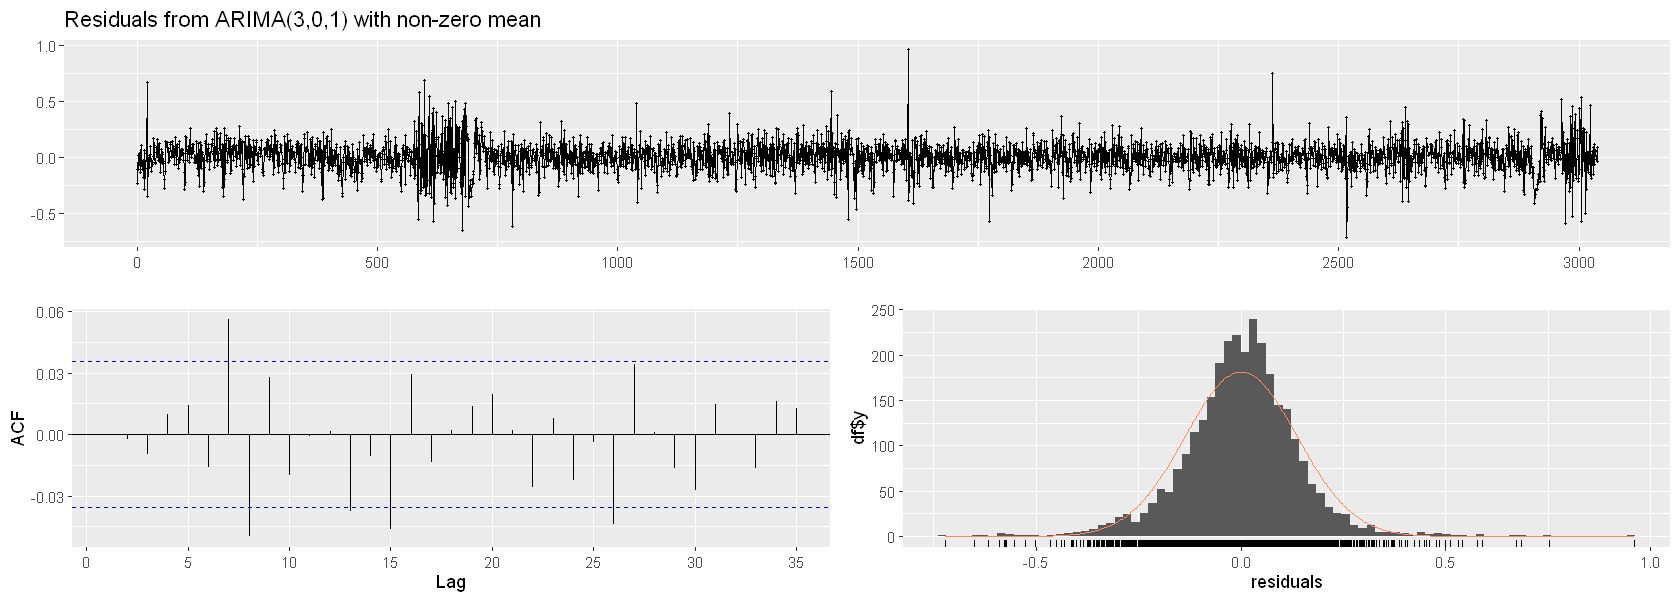

In [14]:
# 4.3 Print selected model summary and diagnostic panel
print(summary(best_model))
checkresiduals(best_model)

### 4.4 Prepare Residual Vector
This cell extracts finite residuals from the selected ARIMA model to reuse across formal residual tests.

In [15]:
# 4.4 Extract finite residuals
resid_vec <- as.numeric(residuals(best_model))
resid_vec <- resid_vec[is.finite(resid_vec)]
cat(sprintf('Residual count used for tests: %d\n', length(resid_vec)))

Residual count used for tests: 3039


## V. Fitting and Diagnostics
The ARIMA(3,0,1) model was fitted to the transformed residuals. However, a model is only considered valid if its remaining residuals ($\hat{e}_t$) behave as independent Gaussian white noise. Formal statistical tests were conducted:

* **Normality (Shapiro-Wilk):** The test yielded $p = 0.000000$, strongly rejecting the null hypothesis of normal distribution. 
* **Overall Autocorrelation (Ljung-Box):** The test yielded $p = 0.001198$, rejecting the null hypothesis of zero remaining autocorrelation.
* **Independence (Runs Test):** The test yielded $p = 0.383753$. Because $p > 0.05$, we fail to reject the null hypothesis, confirming that the *signs* of the residuals are randomly distributed over time.

**Contextual Diagnostic Observations:**
While failing the Shapiro-Wilk and Ljung-Box tests often indicates a poor model in standard finance datasets, it is highly expected here given the astrophysical context. Standard ARIMA models assume symmetric Gaussian noise. A planetary transit is an extreme, asymmetric, deterministic shock (a sharp downward spike). The heavy tails observed in the residuals and the leftover structural autocorrelation are mathematical artifacts of these transit drops. The passing Runs test proves the model captured the core linear sequence, but no purely linear stochastic model can perfectly absorb deterministic astronomical shapes into white noise.

### 4.5 Ljung-Box Test
This cell performs the Ljung-Box test on model residuals to check whether leftover autocorrelation is statistically significant. In this run, p-value $=0.001198$, so we reject the white-noise autocorrelation null at common significance levels: some serial structure remains in residuals.

In [16]:
# 4.5 Ljung-Box test for residual autocorrelation
lb_lag <- min(20, max(5, floor(length(resid_vec) / 5)))
lb_fitdf <- best_order[1] + best_order[3]
lb_test <- Box.test(resid_vec, lag = lb_lag, type = 'Ljung-Box', fitdf = lb_fitdf)

cat(sprintf('Ljung-Box (lag=%d, fitdf=%d): statistic=%.4f, p-value=%.6f\n',
            lb_lag, lb_fitdf, lb_test$statistic, lb_test$p.value))

Ljung-Box (lag=20, fitdf=4): statistic=38.7077, p-value=0.001198


### 4.6 Shapiro-Wilk Normality Test
This cell checks whether residuals are approximately Gaussian. Since Shapiro has an upper sample-size limit, we subsample if needed. Here, $W=0.9682$ with p-value reported as $0.000000$, so residual normality is strongly rejected.

In [17]:
# 4.6 Shapiro-Wilk test for residual normality
shapiro_vec <- resid_vec
if (length(shapiro_vec) > 5000) shapiro_vec <- sample(shapiro_vec, 5000)
shapiro_res <- shapiro.test(shapiro_vec)

cat(sprintf('Shapiro-Wilk: W=%.4f, p-value=%.6f\n',
            shapiro_res$statistic, shapiro_res$p.value))

Shapiro-Wilk: W=0.9682, p-value=0.000000


### 4.7 Runs Test
This cell applies a median-based runs test to evaluate randomness in the sign sequence of residuals. In this run, p-value $=0.383753$, so we do not reject randomness by this test, which contrasts with the Ljung-Box result and suggests dependence is subtle/lag-structured rather than a simple sign-pattern bias.

In [18]:
# 4.7 Median-based runs test for residual randomness
runs_test_median <- function(x) {
  x <- x[is.finite(x)]
  med <- median(x)
  signs <- ifelse(x > med, 1, ifelse(x < med, 0, NA))
  signs <- signs[!is.na(signs)]

  n1 <- sum(signs == 1)
  n2 <- sum(signs == 0)
  n <- n1 + n2
  if (n < 2 || n1 == 0 || n2 == 0) {
    return(data.frame(runs = NA_real_, z = NA_real_, p.value = NA_real_))
  }

  runs <- 1 + sum(abs(diff(signs)))
  mean_runs <- 1 + (2 * n1 * n2) / n
  var_runs <- (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (n^2 * (n - 1))

  if (!is.finite(var_runs) || var_runs <= 0) {
    return(data.frame(runs = runs, z = NA_real_, p.value = NA_real_))
  }

  z <- (runs - mean_runs) / sqrt(var_runs)
  p <- 2 * pnorm(abs(z), lower.tail = FALSE)
  data.frame(runs = runs, z = z, p.value = p)
}

runs_res <- runs_test_median(resid_vec)
cat(sprintf('Runs test: runs=%.0f, z=%.4f, p-value=%.6f\n',
            runs_res$runs, runs_res$z, runs_res$p.value))

Runs test: runs=1544, z=0.8710, p-value=0.383753


### 4.8 QQ Plot of Residuals
This cell isolates the QQ plot so normality departures can be inspected independently from the multi-panel diagnostic output. The current QQ plot shows clear tail deviation from the reference line, matching the Shapiro-Wilk rejection of Gaussian residuals.

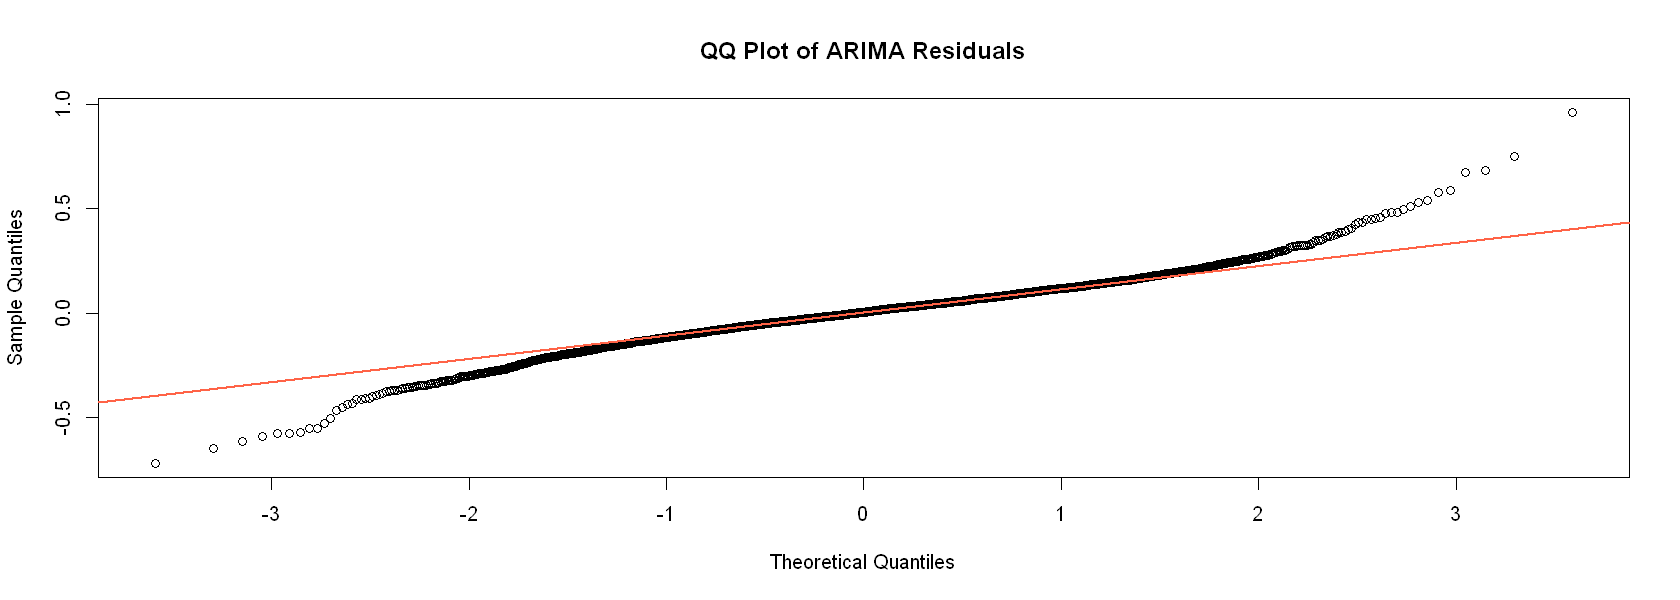

In [19]:
# 4.8 QQ plot for residual normality
qqnorm(resid_vec, main = 'QQ Plot of ARIMA Residuals')
qqline(resid_vec, col = 'tomato', lwd = 2)

### 5.1 Forecast on Transformed Scale and Invert
This cell forecasts on the ARIMA-transformed residual scale, then applies inverse Box-Cox and restores original residual scaling for test-horizon predictions.

In [20]:
# 5.1 Forecast transformed residual process and invert transforms
steps <- nrow(test_df)
forecast_boxcox <- as.numeric(forecast(best_model, h = steps)$mean)

if (abs(lambda_selected - 1) < 1e-12) {
  forecast_resid_scaled <- forecast_boxcox
} else {
  forecast_resid_scaled <- InvBoxCox(forecast_boxcox, lambda_selected)
}

forecast_resid <- (forecast_resid_scaled * scale_selected) - shift_selected
forecast_flux <- train_mean_selected + harmonic_test_selected + forecast_resid

## VI. Forecasting and Performance Evaluation
The final ARIMA(3,0,1) model was utilized alongside the extrapolated two-harmonic baseline to forecast the withheld test set. 

**Theoretical Note on Forecast Inversion:**
Because the ARIMA model was fitted to Box-Cox transformed data ($\lambda \approx 1.35$), the resulting forecast represents the Minimum Mean Square Error (MMSE) forecast on the transformed scale. To compare predictions to the actual observed test flux, an inverse transformation was applied. As established in time series literature, non-linear inverse transformations do not perfectly preserve the true MMSE property, resulting in what is formally termed a "naive forecast" on the original scale.

**Results:**
The forecast achieved a Mean Absolute Error (MAE) of 61.05 and a Root Mean Square Error (RMSE) of 77.34. The fact that RMSE is notably higher than MAE indicates that the model's errors are heavily influenced by large, isolated spikes—specifically, its inability to perfectly predict the exact depth of the sudden transit events.

### 5.2 Forecast Accuracy Metrics
This cell computes MAE and RMSE by comparing reconstructed forecasted flux against observed test flux. For this run, **MAE = 61.056435** and **RMSE = 77.339543**, indicating moderate average error with larger penalties on peak misses.

In [21]:
# 5.2 Compute MAE and RMSE
actual <- test_df$flux
mae <- mean(abs(actual - forecast_flux))
rmse <- sqrt(mean((actual - forecast_flux)^2))

cat(sprintf('MAE : %.6f\n', mae))
cat(sprintf('RMSE: %.6f\n', rmse))

MAE : 61.056435
RMSE: 77.339543


### 5.3 Final Forecast Plot
This final visualization overlays train, test, and forecasted flux. In the current output, the forecast follows the broad low-frequency movement but smooths out fast/local oscillations in the test segment, which is consistent with the RMSE level and residual diagnostics above.

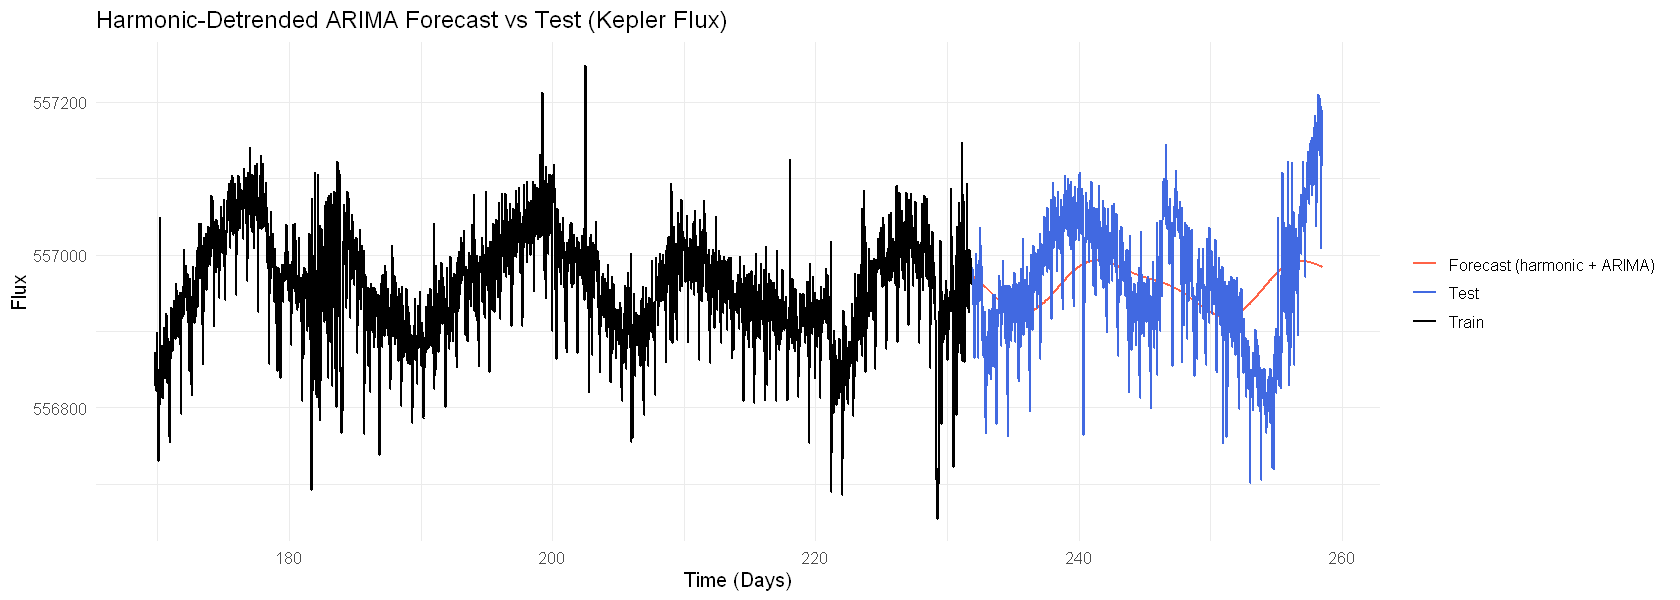

In [22]:
# 5.3 Plot train, test, and forecast
plot_df <- bind_rows(
  data.frame(time = train_df$time, flux = train_df$flux, series = 'Train'),
  data.frame(time = test_df$time, flux = test_df$flux, series = 'Test'),
  data.frame(time = test_df$time, flux = forecast_flux, series = 'Forecast (harmonic + ARIMA)')
)

ggplot(plot_df, aes(x = time, y = flux, color = series)) +
  geom_line(linewidth = 0.7) +
  scale_color_manual(values = c('Train' = 'black', 'Test' = 'royalblue', 'Forecast (harmonic + ARIMA)' = 'tomato')) +
  labs(title = 'Harmonic-Detrended ARIMA Forecast vs Test (Kepler Flux)', x = 'Time (Days)', y = 'Flux', color = NULL) +
  theme_minimal(base_size = 12)

## VII. Model Deficiencies and Conclusion
This analysis successfully mapped the complete time series modeling pipeline onto raw astrophysical photometry. The non-stationary stellar wandering was successfully stabilized via spectral harmonic detrending, and an ARIMA(3,0,1) model effectively captured the remaining stationary stochastic behavior of Kepler-10.

**Deficiencies:**
The primary deficiency of this model lies in the fundamental limitation of ARMA processes when applied to astrophysics. ARMA treats planetary transits as stochastic moving average shocks rather than scheduled, deterministic orbital events. Consequently, the model forecasts exponential decay back to the mean rather than anticipating the sharp, non-linear curvature of a transit.

**Conclusion:**
Ultimately, the ARIMA methodology is highly effective at defining the "normal" behavior and stochastic noise floor of a star. By mathematically mapping the baseline so accurately, models like the one built in this report allow astronomers to easily identify transits as statistically significant anomalies from the predicted forecast, proving the power of time series analysis in exoplanet discovery.